### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
np.random.seed(42)
tf.set_random_seed(42)
tf.__version__
tf.keras.__version__
tf.reset_default_graph()
from tensorflow.keras import datasets, layers, models

#### Collect Fashion mnist data from tf.keras.datasets 

In [2]:
(trainX, trainY), (testX, testY) = tf.keras.datasets.fashion_mnist.load_data()
print("Shape of trainX:", trainX.shape)
print("Shape of trainY:", trainY.shape)
print("Shape of testX:", testX.shape)
print("Shape of testY:", testY.shape)

Shape of trainX: (60000, 28, 28)
Shape of trainY: (60000,)
Shape of testX: (10000, 28, 28)
Shape of testY: (10000,)


In [0]:
# Define the text labels
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2 
                        "Dress",        # index 3 
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6 
                        "Sneaker",      # index 7 
                        "Bag",          # index 8 
                        "Ankle boot"]   # index 9

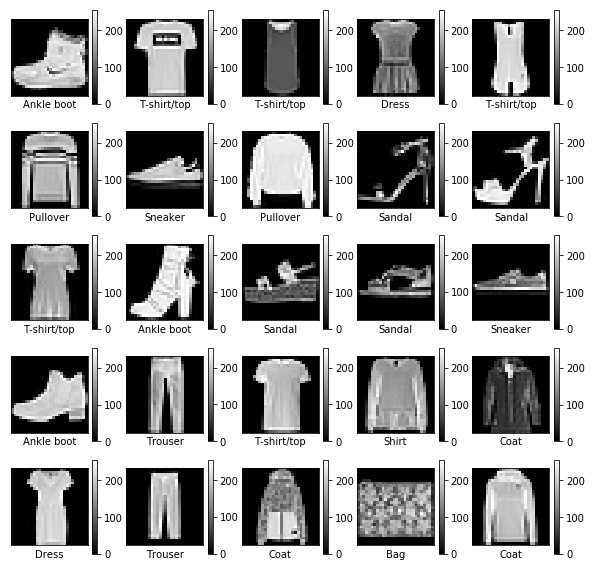

In [4]:
# Visualize sample data for overview
def plot_images(image_label_tuple, grid_nums):
    plt.figure(figsize=(2*grid_nums, 2*grid_nums))
    for i in range(grid_nums**2):
        plt.subplot(grid_nums, grid_nums, i+1)
        plt.imshow(image_label_tuple[0][i], cmap='gray')
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(fashion_mnist_labels[image_label_tuple[1][i]])
        plt.grid(False)
    plt.show()    
plot_images((trainX, trainY),5)

#### Change train and test labels into one-hot vectors

In [5]:
trainY = tf.keras.utils.to_categorical(trainY)
print("Shape of trainY:", trainY.shape)
testY = tf.keras.utils.to_categorical(testY)
print("Shape of testY:", testY.shape)


Shape of trainY: (60000, 10)
Shape of testY: (10000, 10)


#### Build the Graph

#### Initialize model, reshape & normalize data

In [0]:
tf.keras.backend.clear_session()
# Initialize model, reshape & normalize the data
model = tf.keras.models.Sequential()
# Reshape the data from 2D (28,28) to 3D(28,28, 1)
model.add(tf.keras.layers.Reshape(target_shape=(28,28,1), input_shape=(28,28)))
# Normalize the data
model.add(tf.keras.layers.BatchNormalization())

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [8]:
# Flatten the output
model.add(tf.keras.layers.Flatten())
# Add first Dense layer
model.add(tf.keras.layers.Dense(200, activation='relu'))
# Add first Dense layer
model.add(tf.keras.layers.Dense(100, activation='relu'))
# Add Droput layer
model.add(tf.keras.layers.Dropout(rate=0.25))

W0825 16:25:00.972609 139723947214720 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
# Add output layer
model.add(tf.keras.layers.Dense(10, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01)))

In [10]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 28, 28, 1)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 1)         4         
_________________________________________________________________
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1

**Train the model**

In [11]:
model.fit(trainX, trainY, batch_size=32, validation_data=(testX, testY), shuffle=True, epochs=10)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 11s 191us/sample - loss: 0.5589 - acc: 0.8217 - val_loss: 0.4230 - val_acc: 0.8586
Epoch 2/10
60000/60000 [==============================] - 11s 184us/sample - loss: 0.4016 - acc: 0.8622 - val_loss: 0.3973 - val_acc: 0.8647
Epoch 3/10
60000/60000 [==============================] - 11s 188us/sample - loss: 0.3594 - acc: 0.8763 - val_loss: 0.3899 - val_acc: 0.8673
Epoch 4/10
60000/60000 [==============================] - 11s 189us/sample - loss: 0.3378 - acc: 0.8826 - val_loss: 0.3915 - val_acc: 0.8625
Epoch 5/10
60000/60000 [==============================] - 11s 188us/sample - loss: 0.3125 - acc: 0.8903 - val_loss: 0.3679 - val_acc: 0.8749
Epoch 6/10
60000/60000 [==============================] - 11s 190us/sample - loss: 0.3004 - acc: 0.8935 - val_loss: 0.3579 - val_acc: 0.8737
Epoch 7/10
60000/60000 [==============================] - 11s 190us/sample - loss: 0.2872 - acc: 0.8991 

In [12]:
# Evaluate score for last model in the iteration
score = model.evaluate(testX, testY)
print(score)

10000/10000 [==============================] - 0s 49us/sample - loss: 0.3466 - acc: 0.8837
[0.34659775795936587, 0.8837]
